## AGN Homework 2 – Galaxy Classification

In [1]:
%%capture

import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

from astroquery.sdss import SDSS

from astropy.io import fits

```sql
SELECT
    g.oiii_5007_flux, g.nii_6584_flux, g.h_beta_flux, g.h_alpha_flux,
    (g.oiii_5007_flux / g.h_beta_flux) AS oiii_hbeta_ratio,
    (g.nii_6584_flux / g.h_alpha_flux) AS nii_halpha_ratio,
    s.class, s.subclass
FROM SpecObj AS s
JOIN galSpecLine AS g ON s.specobjid = g.specobjid
WHERE s.class = 'GALAXY' 
  AND s.snmedian_g > 40
  AND g.oiii_5007_eqw < 0
  AND g.nii_6584_eqw < 0
  AND g.h_beta_eqw < 0
  AND g.h_alpha_eqw < 0
  AND g.oiii_5007_flux > 5
  AND g.nii_6584_flux > 5
  AND g.h_beta_flux > 5
  AND g.h_alpha_flux > 5
  AND g.oiii_5007_flux > 5 * g.oiii_5007_flux_err
  AND g.nii_6584_flux > 5 * g.nii_6584_flux_err
  AND g.h_beta_flux > 5 * g.h_beta_flux_err
  AND g.h_alpha_flux > 5 * g.h_alpha_flux_err
  AND (2.355 * g.sigma_forbidden) < 500
  AND (2.355 * g.sigma_balmer) < 500
```

In [2]:
sql = '''SELECT
    g.oiii_5007_flux, g.nii_6584_flux, g.h_beta_flux, g.h_alpha_flux,
    (g.oiii_5007_flux / g.h_beta_flux) AS oiii_hbeta_ratio,
    (g.nii_6584_flux / g.h_alpha_flux) AS nii_halpha_ratio,
    s.class, s.subclass
FROM SpecObj AS s
JOIN galSpecLine AS g ON s.specobjid = g.specobjid
WHERE s.class = 'GALAXY' 
  AND s.snmedian_g > 40
  AND g.oiii_5007_eqw < 0
  AND g.nii_6584_eqw < 0
  AND g.h_beta_eqw < 0
  AND g.h_alpha_eqw < 0
  AND g.oiii_5007_flux > 5
  AND g.nii_6584_flux > 5
  AND g.h_beta_flux > 5
  AND g.h_alpha_flux > 5
  AND g.oiii_5007_flux > 5 * g.oiii_5007_flux_err
  AND g.nii_6584_flux > 5 * g.nii_6584_flux_err
  AND g.h_beta_flux > 5 * g.h_beta_flux_err
  AND g.h_alpha_flux > 5 * g.h_alpha_flux_err
  AND (2.355 * g.sigma_forbidden) < 500
  AND (2.355 * g.sigma_balmer) < 500'''

table = SDSS.query_sql(sql)

df_tab = table.to_pandas()
df_tab.to_csv('a_tab.csv', index=False)

print(f"found {len(df_tab)} objects with subclasses {', '.join(map(str, df_tab['subclass'].dropna().unique()))}\n")

df_tab.dropna().head(10).style.hide()

found 958 objects with subclasses BROADLINE, STARBURST, STARFORMING, AGN BROADLINE, AGN, STARFORMING BROADLINE, STARBURST BROADLINE



oiii_5007_flux,nii_6584_flux,h_beta_flux,h_alpha_flux,oiii_hbeta_ratio,nii_halpha_ratio,class,subclass
34.374620,134.446400,30.098180,116.716200,1.142083,1.151908,GALAXY,BROADLINE
2402.944000,3451.395000,3685.008000,13171.200000,0.652087,0.262041,GALAXY,STARBURST
45.401650,362.739100,201.460900,835.793900,0.225362,0.434005,GALAXY,STARFORMING
57.489520,304.132600,157.620400,703.285900,0.364734,0.432445,GALAXY,STARFORMING
111.137600,128.614600,58.325860,161.072800,1.905460,0.798488,GALAXY,BROADLINE
278.627100,1349.898000,203.431300,859.090600,1.369637,1.571311,GALAXY,AGN BROADLINE
44.031220,412.711500,212.141200,1010.639000,0.207556,0.408367,GALAXY,STARFORMING
937.167200,326.486400,599.948700,1766.253000,1.562079,0.184847,GALAXY,STARBURST
213.446700,173.324200,245.949100,728.445700,0.867849,0.237937,GALAXY,STARFORMING
221.848800,1898.237000,1058.584000,5413.769000,0.209571,0.350631,GALAXY,STARBURST


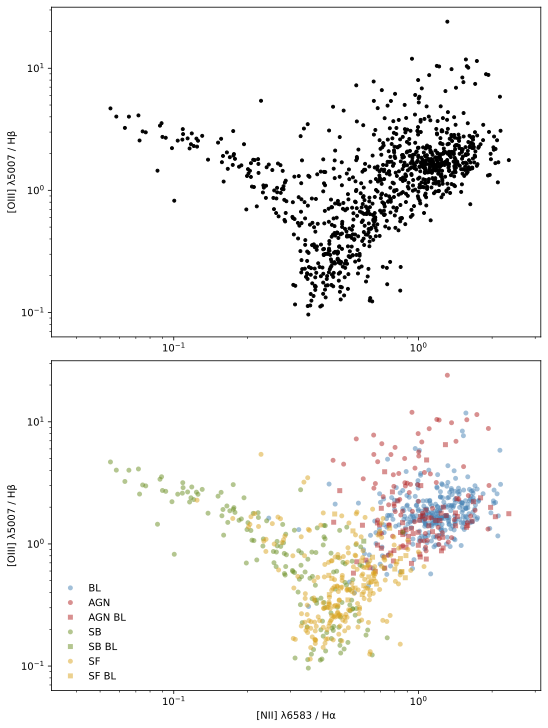

In [3]:
x_agn = df_tab[(df_tab['subclass'] == 'AGN')]['nii_halpha_ratio']
y_agn = df_tab[(df_tab['subclass'] == 'AGN')]['oiii_hbeta_ratio']

x_bl = df_tab[(df_tab['subclass'] == 'BROADLINE')]['nii_halpha_ratio']
y_bl = df_tab[(df_tab['subclass'] == 'BROADLINE')]['oiii_hbeta_ratio']

x_sb = df_tab[(df_tab['subclass'] == 'STARBURST')]['nii_halpha_ratio']
y_sb = df_tab[(df_tab['subclass'] == 'STARBURST')]['oiii_hbeta_ratio']

x_sf = df_tab[(df_tab['subclass'] == 'STARFORMING')]['nii_halpha_ratio']
y_sf = df_tab[(df_tab['subclass'] == 'STARFORMING')]['oiii_hbeta_ratio']

x_agn_bl = df_tab[(df_tab['subclass'] == 'AGN BROADLINE')]['nii_halpha_ratio']
y_agn_bl = df_tab[(df_tab['subclass'] == 'AGN BROADLINE')]['oiii_hbeta_ratio']

x_sb_bl = df_tab[(df_tab['subclass'] == 'STARBURST BROADLINE')]['nii_halpha_ratio']
y_sb_bl = df_tab[(df_tab['subclass'] == 'STARBURST BROADLINE')]['oiii_hbeta_ratio']

x_sf_bl = df_tab[(df_tab['subclass'] == 'STARFORMING BROADLINE')]['nii_halpha_ratio']
y_sf_bl = df_tab[(df_tab['subclass'] == 'STARFORMING BROADLINE')]['oiii_hbeta_ratio']

%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

circ_args = {'mec': 'none', 'mew': 0, 'ms': 10, 'alpha': 0.5}
squa_args = {'mec': 'none', 'mew': 0, 'ms': 5, 'alpha': 0.5}

fig, axs = plt.subplots(2, 1, figsize=[7.5, 10])

axs[0].plot(df_tab['nii_halpha_ratio'], df_tab['oiii_hbeta_ratio'], 'k.')

axs[0].set_xscale('log')
axs[0].set_yscale('log')

axs[0].set_xlim(10**(-1.5), 10**(0.5))
axs[0].set_ylim(10**(-1.2), 10**(1.5))

axs[0].set_ylabel('[OIII] λ5007 / Hβ')

axs[1].plot(x_bl, y_bl, '.', c='steelblue', label='BL', **circ_args)

axs[1].plot(x_agn, y_agn, '.', c='firebrick', label='AGN', **circ_args)
axs[1].plot(x_agn_bl, y_agn_bl, 's', c='firebrick', label='AGN BL', **squa_args)

axs[1].plot(x_sb, y_sb, '.', c='olivedrab', label='SB', **circ_args)
axs[1].plot(x_sb_bl, y_sb_bl, 's', c='olivedrab', label='SB BL', **squa_args)

axs[1].plot(x_sf, y_sf, '.', c='goldenrod', label='SF', **circ_args)
axs[1].plot(x_sf_bl, y_sf_bl, 's', c='goldenrod', label='SF BL', **squa_args)

axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[1].set_xlim(10**(-1.5), 10**(0.5))
axs[1].set_ylim(10**(-1.2), 10**(1.5))

axs[1].set_xlabel('[NII] λ6583 / Hα')
axs[1].set_ylabel('[OIII] λ5007 / Hβ')

axs[1].legend()

plt.show()
plt.close()

#### Kewley (2001)

$$\log(\symup{[OIII]}/\symup{Hβ}) = \frac{0.61}{\log(\symup{[NII]}/\symup{Hα}) − 0.47} + 1.19$$

#### Kauffmann (2003)

$$\log(\symup{[OIII]}/\symup{Hβ}) = \frac{0.61}{\log(\symup{[NII]}/\symup{Hα}) - 0.05} + 1.3$$

#### Schawinski (2007)

$$\log(\symup{[O III]}/\symup{Hβ}) = 1.05 \log(\symup{[N II]}/\symup{Hα}) + 0.45$$

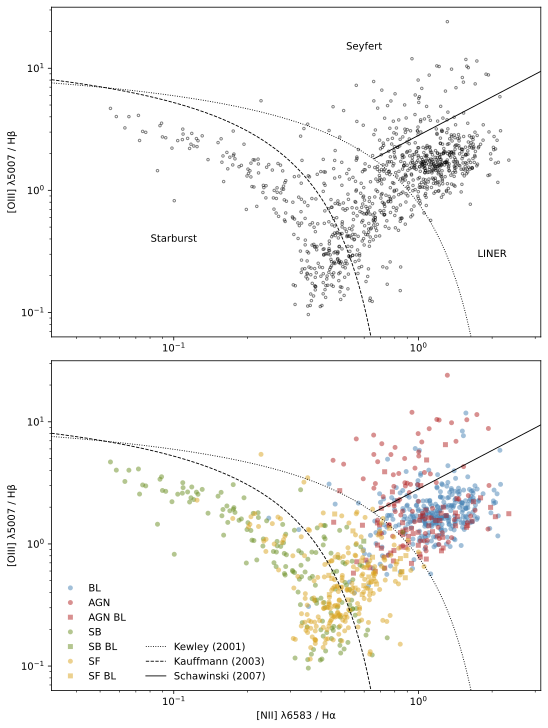

In [4]:
x = np.logspace(-1.5, 0.5, 400)

y_kewl = 10**(0.61 / (np.log10(x) - 0.47) + 1.19)
y_kewl = y_kewl[x < 10**(0.47)]
x_kewl = x[x < 10**(0.47)]

y_kauf = 10**(0.61 / (np.log10(x) - 0.05) + 1.3)
y_kauf = y_kauf[x < 10**(0.05)]
x_kauf = x[x < 10**(0.05)]

y_scha = 10**(1.05 * np.log10(x) + 0.45)
x_scha = x[np.argmin(np.abs(y_scha[:len(y_kewl)] - y_kewl)):]
y_scha = y_scha[np.argmin(np.abs(y_scha[:len(y_kewl)] - y_kewl)):]

fig, axs = plt.subplots(2, 1, figsize=[7.5, 10])

axs[0].plot(df_tab['nii_halpha_ratio'], df_tab['oiii_hbeta_ratio'], '.', mfc='none', mec='k', ms=5, alpha=0.5)

axs[0].plot(x_kewl, y_kewl, 'k:', lw=0.9)
axs[0].plot(x_kauf, y_kauf, 'k--', lw=0.9)
axs[0].plot(x_scha, y_scha, 'k-', lw=0.9)

axs[0].text(2, 0.3, 'LINER', va='center', ha='center')
axs[0].text(0.6, 15, 'Seyfert', va='center', ha='center')
axs[0].text(0.1, 0.4, 'Starburst', va='center', ha='center')

axs[0].set_xscale('log')
axs[0].set_yscale('log')

axs[0].set_xlim(10**(-1.5), 10**(0.5))
axs[0].set_ylim(10**(-1.2), 10**(1.5))

axs[0].set_ylabel('[OIII] λ5007 / Hβ')

axs[1].plot(x_bl, y_bl, '.', c='steelblue', label='BL', **circ_args)

axs[1].plot(x_agn, y_agn, '.', c='firebrick', label='AGN', **circ_args)
axs[1].plot(x_agn_bl, y_agn_bl, 's', c='firebrick', label='AGN BL', **squa_args)

axs[1].plot(x_sb, y_sb, '.', c='olivedrab', label='SB', **circ_args)
axs[1].plot(x_sb_bl, y_sb_bl, 's', c='olivedrab', label='SB BL', **squa_args)

axs[1].plot(x_sf, y_sf, '.', c='goldenrod', label='SF', **circ_args)
axs[1].plot(x_sf_bl, y_sf_bl, 's', c='goldenrod', label='SF BL', **squa_args)

axs[1].plot([], [], ' ', label=' ')
axs[1].plot([], [], ' ', label=' ')
axs[1].plot([], [], ' ', label=' ')
axs[1].plot([], [], ' ', label=' ')

axs[1].plot(x_kewl, y_kewl, 'k:', lw=0.9, label='Kewley (2001)')
axs[1].plot(x_kauf, y_kauf, 'k--', lw=0.9, label='Kauffmann (2003)')
axs[1].plot(x_scha, y_scha, 'k-', lw=0.9, label='Schawinski (2007)')

axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[1].set_xlim(10**(-1.5), 10**(0.5))
axs[1].set_ylim(10**(-1.2), 10**(1.5))

axs[1].set_xlabel('[NII] λ6583 / Hα')
axs[1].set_ylabel('[OIII] λ5007 / Hβ')

axs[1].legend(ncol=2)

plt.savefig('bpt.pdf')

plt.show()
plt.close()

```sql
SELECT 
    (g.oiii_5007_flux / g.h_beta_flux) AS oiii_hbeta_ratio,
    (g.nii_6584_flux / g.h_alpha_flux) AS nii_halpha_ratio
FROM SpecObj AS s
JOIN galSpecLine AS g ON s.specobjid = g.specobjid
WHERE s.class = 'GALAXY' 
  AND s.snmedian_g > 10
  AND g.oiii_5007_eqw < -0.1
  AND g.nii_6584_eqw < -0.1
  AND g.h_beta_eqw < -0.1
  AND g.h_alpha_eqw < -0.1
  AND g.oiii_5007_flux > 5
  AND g.nii_6584_flux > 5
  AND g.h_beta_flux > 5
  AND g.h_alpha_flux > 5
  AND g.oiii_5007_flux > 3 * g.oiii_5007_flux_err
  AND g.nii_6584_flux > 3 * g.nii_6584_flux_err
  AND g.h_beta_flux > 3 * g.h_beta_flux_err
  AND g.h_alpha_flux > 3 * g.h_alpha_flux_err
  AND (2.355 * g.sigma_forbidden) < 500
  AND (2.355 * g.sigma_balmer) < 500
```

In [5]:
sql = '''SELECT 
    (g.oiii_5007_flux / g.h_beta_flux) AS oiii_hbeta_ratio,
    (g.nii_6584_flux / g.h_alpha_flux) AS nii_halpha_ratio
FROM SpecObj AS s
JOIN galSpecLine AS g ON s.specobjid = g.specobjid
WHERE s.class = 'GALAXY' 
  AND s.snmedian_g > 10
  AND g.oiii_5007_eqw < -0.1
  AND g.nii_6584_eqw < -0.1
  AND g.h_beta_eqw < -0.1
  AND g.h_alpha_eqw < -0.1
  AND g.oiii_5007_flux > 5
  AND g.nii_6584_flux > 5
  AND g.h_beta_flux > 5
  AND g.h_alpha_flux > 5
  AND g.oiii_5007_flux > 3 * g.oiii_5007_flux_err
  AND g.nii_6584_flux > 3 * g.nii_6584_flux_err
  AND g.h_beta_flux > 3 * g.h_beta_flux_err
  AND g.h_alpha_flux > 3 * g.h_alpha_flux_err
  AND (2.355 * g.sigma_forbidden) < 500
  AND (2.355 * g.sigma_balmer) < 500'''

table = SDSS.query_sql(sql)

df_ful = table.to_pandas()

print(f"found {len(df_ful)} objects")

found 153231 objects


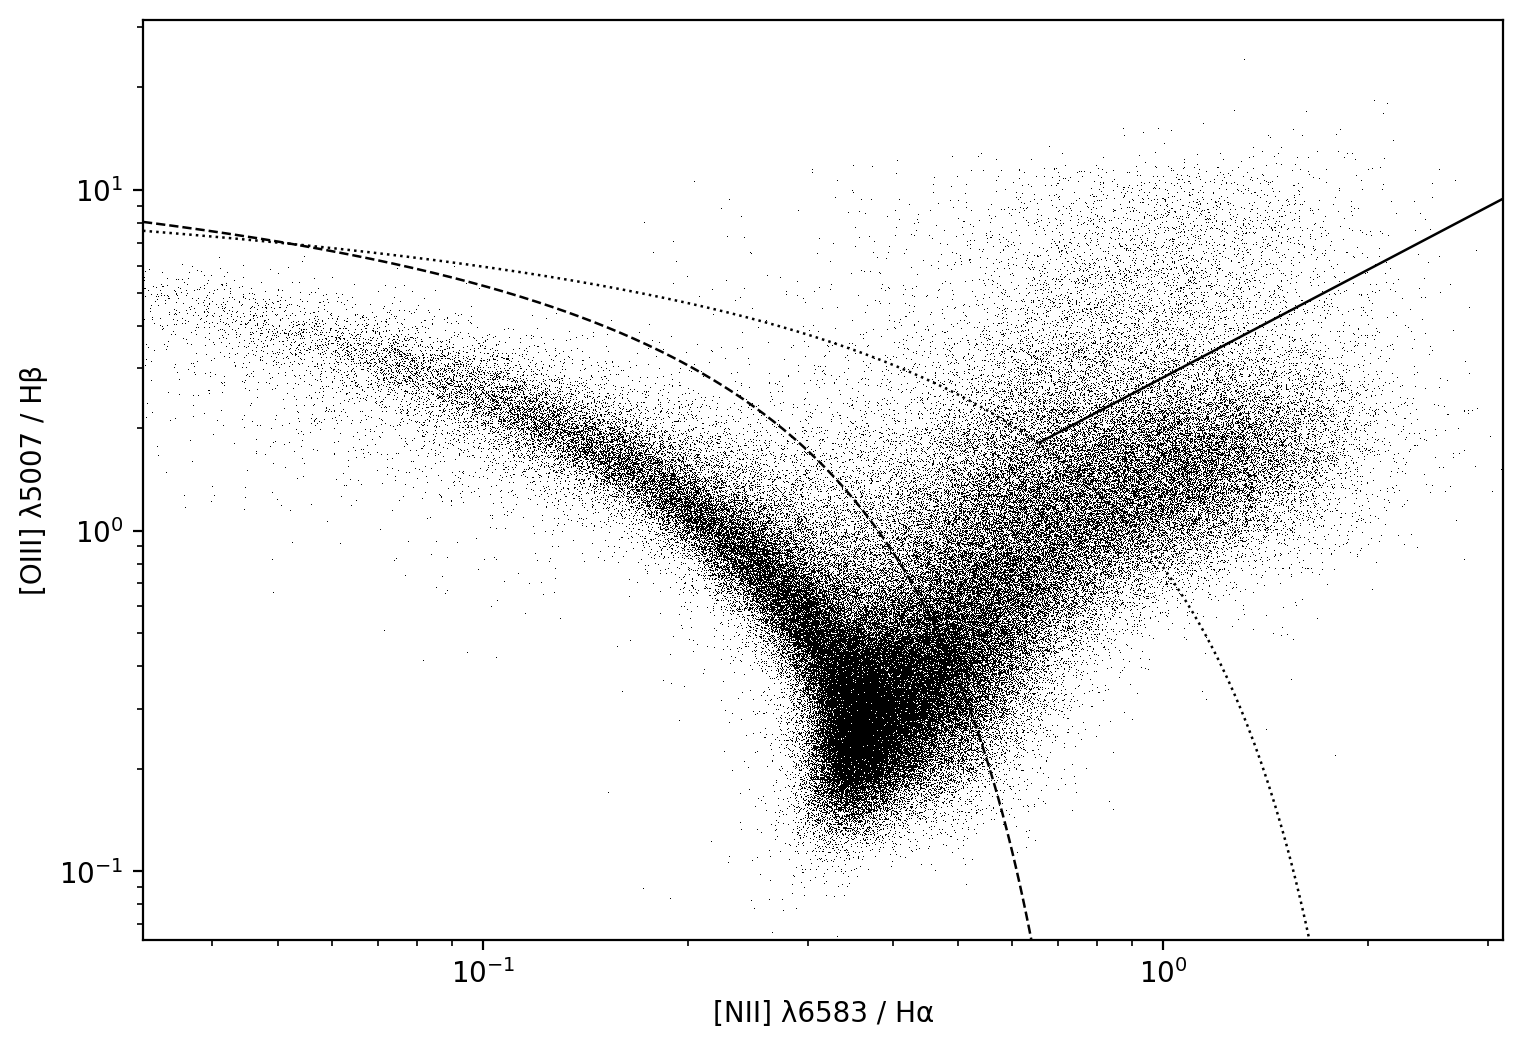

In [6]:
%config InlineBackend.figure_formats = ['retina']

fig, ax = plt.subplots(1, 1, figsize=[7.5, 5.125])

ax.plot(df_ful['nii_halpha_ratio'], df_ful['oiii_hbeta_ratio'], 'k,')

ax.plot(x_kewl, y_kewl, 'k:', lw=0.9)
ax.plot(x_kauf, y_kauf, 'k--', lw=0.9)
ax.plot(x_scha, y_scha, 'k-', lw=0.9)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(10**(-1.5), 10**(0.5))
ax.set_ylim(10**(-1.2), 10**(1.5))

ax.set_xlabel('[NII] λ6583 / Hα')
ax.set_ylabel('[OIII] λ5007 / Hβ')

plt.show()
plt.close()

%config InlineBackend.figure_formats = ['svg']

```sql
SELECT 
    w.w1mpro, w.w2mpro, w.w3mpro,
    (w.w1mpro - w.w2mpro) AS w1_w2_color,
    (w.w2mpro - w.w3mpro) AS w2_w3_color,
    (g.oiii_5007_flux / g.h_beta_flux) AS oiii_hbeta_ratio,
    (g.nii_6584_flux / g.h_alpha_flux) AS nii_halpha_ratio,
    s.class, s.subclass
FROM SpecObj AS s
JOIN galSpecLine AS g ON s.specobjid = g.specobjid
JOIN PhotoTag AS p ON s.bestobjid = p.objid
JOIN wise_xmatch AS x ON p.objid = x.sdss_objid
JOIN wise_allsky AS w ON x.wise_cntr = w.cntr
WHERE s.class = 'GALAXY' 
  AND s.snmedian_g > 40
  AND g.oiii_5007_eqw < 0
  AND g.nii_6584_eqw < 0
  AND g.h_beta_eqw < 0
  AND g.h_alpha_eqw < 0
  AND g.oiii_5007_flux > 5
  AND g.nii_6584_flux > 5
  AND g.h_beta_flux > 5
  AND g.h_alpha_flux > 5
  AND g.oiii_5007_flux > 5 * g.oiii_5007_flux_err
  AND g.nii_6584_flux > 5 * g.nii_6584_flux_err
  AND g.h_beta_flux > 5 * g.h_beta_flux_err
  AND g.h_alpha_flux > 5 * g.h_alpha_flux_err
  AND (2.355 * g.sigma_forbidden) < 500
  AND (2.355 * g.sigma_balmer) < 500
```

In [7]:
df_web = pd.read_csv('c_web.csv', skiprows=1)

print(f"found {len(df_web)} objects\n")

df_web.dropna().head(10).style.hide()

found 944 objects



w1mpro,w2mpro,w3mpro,w1_w2_color,w2_w3_color,oiii_hbeta_ratio,nii_halpha_ratio,class,subclass
12.246000,12.243000,9.899000,0.003000,2.344000,1.530543,1.326099,GALAXY,BROADLINE
11.420000,11.467000,9.908000,-0.047000,1.559000,0.589734,0.843344,GALAXY,BROADLINE
11.381000,11.416000,9.912000,-0.035001,1.504001,0.725253,0.789872,GALAXY,AGN BROADLINE
11.811000,11.854000,10.854000,-0.043000,1.000000,3.444162,1.418123,GALAXY,BROADLINE
11.996000,11.941000,9.768000,0.055000,2.173000,3.076559,2.165079,GALAXY,BROADLINE
11.288000,11.378000,9.772000,-0.090000,1.606000,3.775190,0.830764,GALAXY,AGN
12.726000,12.696000,9.773000,0.030000,2.923000,1.290822,0.358576,GALAXY,STARFORMING
12.885000,12.839000,9.773000,0.046000,3.066000,1.377488,0.202080,GALAXY,STARFORMING
11.907000,11.961000,9.779000,-0.054001,2.182000,1.793976,0.408278,GALAXY,STARFORMING
11.614000,11.619000,9.784000,-0.005000,1.835000,2.572430,2.095444,GALAXY,BROADLINE


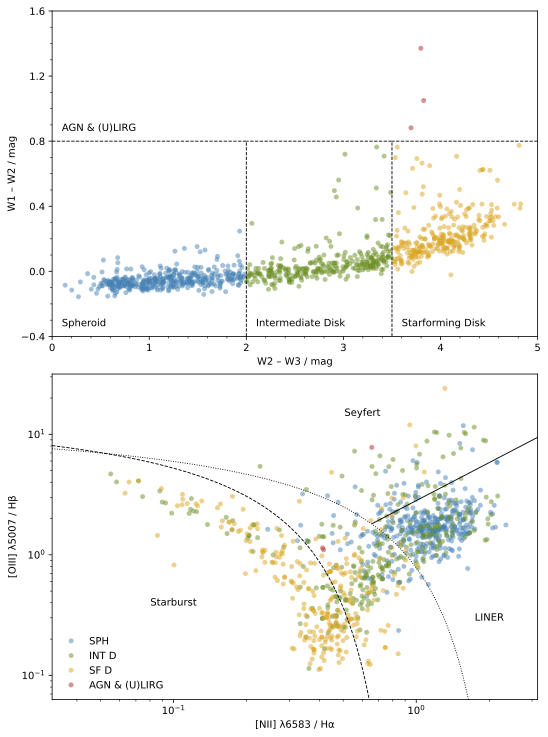

In [8]:
df_sph = df_web[(df_web['w1_w2_color'] <= 0.8) & (df_web['w2_w3_color'] < 2.0)]
df_int = df_web[(df_web['w1_w2_color'] <= 0.8) & (2.0 <= df_web['w2_w3_color']) & (df_web['w2_w3_color'] < 3.5)]
df_sfd = df_web[(df_web['w1_w2_color'] <= 0.8) & (3.5 <= df_web['w2_w3_color'])]
df_agn = df_web[df_web['w1_w2_color'] > 0.8]

fig, axs = plt.subplots(2, 1, figsize=[7.5, 10.125])

axs[0].plot(df_sph['w2_w3_color'], df_sph['w1_w2_color'], '.', c='steelblue', **circ_args)
axs[0].plot(df_int['w2_w3_color'], df_int['w1_w2_color'], '.', c='olivedrab', **circ_args)
axs[0].plot(df_sfd['w2_w3_color'], df_sfd['w1_w2_color'], '.', c='goldenrod', **circ_args)
axs[0].plot(df_agn['w2_w3_color'], df_agn['w1_w2_color'], '.', c='firebrick', **circ_args)

axs[0].plot([2.0, 2.0, 0.0], [-0.4, 0.8, 0.8], 'k--', lw=0.9)
axs[0].plot([3.5, 3.5, 2.0], [-0.4, 0.8, 0.8], 'k--', lw=0.9)
axs[0].plot([5.0, 3.5], [0.8, 0.8], 'k--', lw=0.9)

axs[0].text(0.10, 0.85, 'AGN & (U)LIRG', va='bottom', ha='left')
axs[0].text(0.10, -0.35, 'Spheroid', va='bottom', ha='left')
axs[0].text(2.10, -0.35, 'Intermediate Disk', va='bottom', ha='left')
axs[0].text(3.60, -0.35, 'Starforming Disk', va='bottom', ha='left')

axs[0].set_xlim(0, 5)
axs[0].set_ylim(-0.4, 1.6)

axs[0].set_xlabel('W2 – W3 / mag')
axs[0].set_ylabel('W1 – W2 / mag')

axs[0].set_yticks(np.linspace(-0.4, 1.6, 6))

axs[1].plot(df_sph['nii_halpha_ratio'], df_sph['oiii_hbeta_ratio'], '.', c='steelblue', label='SPH', **circ_args)
axs[1].plot(df_int['nii_halpha_ratio'], df_int['oiii_hbeta_ratio'], '.', c='olivedrab', label='INT D', **circ_args)
axs[1].plot(df_sfd['nii_halpha_ratio'], df_sfd['oiii_hbeta_ratio'], '.', c='goldenrod', label='SF D', **circ_args)
axs[1].plot(df_agn['nii_halpha_ratio'], df_agn['oiii_hbeta_ratio'], '.', c='firebrick', label='AGN & (U)LIRG', **circ_args)

axs[1].plot(x_kewl, y_kewl, 'k:', lw=0.9)
axs[1].plot(x_kauf, y_kauf, 'k--', lw=0.9)
axs[1].plot(x_scha, y_scha, 'k-', lw=0.9)

axs[1].text(2, 0.3, 'LINER', va='center', ha='center')
axs[1].text(0.6, 15, 'Seyfert', va='center', ha='center')
axs[1].text(0.1, 0.4, 'Starburst', va='center', ha='center')

axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[1].set_xlim(10**(-1.5), 10**(0.5))
axs[1].set_ylim(10**(-1.2), 10**(1.5))

axs[1].set_xlabel('[NII] λ6583 / Hα')
axs[1].set_ylabel('[OIII] λ5007 / Hβ')

axs[1].legend(loc='lower left')

plt.show()
plt.close()

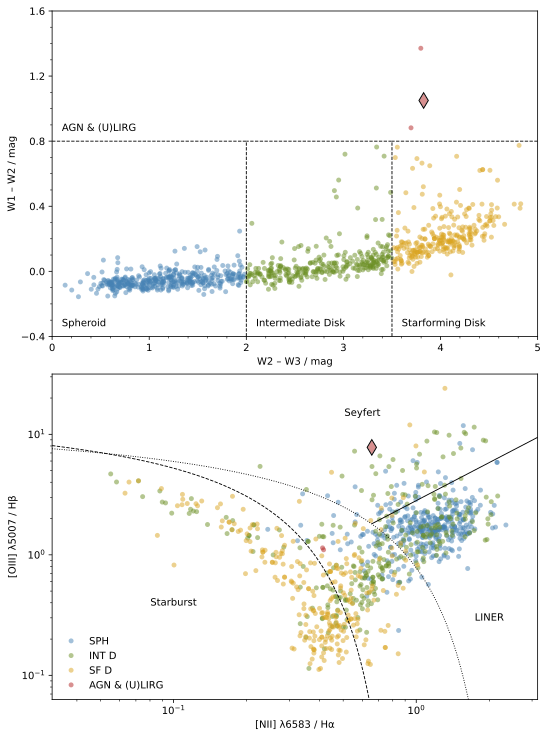

In [9]:
select = df_agn.sample(n=1, random_state=321)

fig, axs = plt.subplots(2, 1, figsize=[7.5, 10.125])

axs[0].plot(df_sph['w2_w3_color'], df_sph['w1_w2_color'], '.', c='steelblue', **circ_args)
axs[0].plot(df_int['w2_w3_color'], df_int['w1_w2_color'], '.', c='olivedrab', **circ_args)
axs[0].plot(df_sfd['w2_w3_color'], df_sfd['w1_w2_color'], '.', c='goldenrod', **circ_args)
axs[0].plot(df_agn['w2_w3_color'], df_agn['w1_w2_color'], '.', c='firebrick', **circ_args)

axs[0].plot([2.0, 2.0, 0.0], [-0.4, 0.8, 0.8], 'k--', lw=0.9)
axs[0].plot([3.5, 3.5, 2.0], [-0.4, 0.8, 0.8], 'k--', lw=0.9)
axs[0].plot([5.0, 3.5], [0.8, 0.8], 'k--', lw=0.9)

axs[0].plot(select['w2_w3_color'], select['w1_w2_color'], 'wd', ms=10)
axs[0].plot(select['w2_w3_color'], select['w1_w2_color'], 'd', c='firebrick', **circ_args)
axs[0].plot(select['w2_w3_color'], select['w1_w2_color'], 'd', mfc='none', mec='k', ms=11)

axs[0].text(0.10, 0.85, 'AGN & (U)LIRG', va='bottom', ha='left')
axs[0].text(0.10, -0.35, 'Spheroid', va='bottom', ha='left')
axs[0].text(2.10, -0.35, 'Intermediate Disk', va='bottom', ha='left')
axs[0].text(3.60, -0.35, 'Starforming Disk', va='bottom', ha='left')

axs[0].set_xlim(0, 5)
axs[0].set_ylim(-0.4, 1.6)

axs[0].set_xlabel('W2 – W3 / mag')
axs[0].set_ylabel('W1 – W2 / mag')

axs[0].set_yticks(np.linspace(-0.4, 1.6, 6))

axs[1].plot(df_sph['nii_halpha_ratio'], df_sph['oiii_hbeta_ratio'], '.', c='steelblue', label='SPH', **circ_args)
axs[1].plot(df_int['nii_halpha_ratio'], df_int['oiii_hbeta_ratio'], '.', c='olivedrab', label='INT D', **circ_args)
axs[1].plot(df_sfd['nii_halpha_ratio'], df_sfd['oiii_hbeta_ratio'], '.', c='goldenrod', label='SF D', **circ_args)
axs[1].plot(df_agn['nii_halpha_ratio'], df_agn['oiii_hbeta_ratio'], '.', c='firebrick', label='AGN & (U)LIRG', **circ_args)

axs[1].plot(x_kewl, y_kewl, 'k:', lw=0.9)
axs[1].plot(x_kauf, y_kauf, 'k--', lw=0.9)
axs[1].plot(x_scha, y_scha, 'k-', lw=0.9)

axs[1].plot(select['nii_halpha_ratio'], select['oiii_hbeta_ratio'], 'wd', ms=10)
axs[1].plot(select['nii_halpha_ratio'], select['oiii_hbeta_ratio'], 'd', c='firebrick', **circ_args)
axs[1].plot(select['nii_halpha_ratio'], select['oiii_hbeta_ratio'], 'd', mfc='none', mec='k', ms=11)

axs[1].text(2, 0.3, 'LINER', va='center', ha='center')
axs[1].text(0.6, 15, 'Seyfert', va='center', ha='center')
axs[1].text(0.1, 0.4, 'Starburst', va='center', ha='center')

axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[1].set_xlim(10**(-1.5), 10**(0.5))
axs[1].set_ylim(10**(-1.2), 10**(1.5))

axs[1].set_xlabel('[NII] λ6583 / Hα')
axs[1].set_ylabel('[OIII] λ5007 / Hβ')

axs[1].legend(loc='lower left')

plt.savefig('wise.pdf')

plt.show()
plt.close()